In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance

def plot_imp(imp, feat_names, title):
    """Plot feature importances as horizontal bars."""
    fig, ax = plt.subplots(figsize=(6, len(feat_names)*0.4))
    idxs = np.argsort(imp)
    ax.barh(range(len(idxs)), imp[idxs], color='steelblue')
    ax.set_yticks(range(len(idxs)))
    ax.set_yticklabels(np.array(feat_names)[idxs])
    ax.set_xlabel("Importance")
    ax.set_title(title)
    return ax

Decision trees and Random forests have feature importance based on impurity decrease builtin. It can be accessed using the `clf.feature_importances_` field.
pass it to the `plot_imp` function to visualize them

# Feature Importances in Entscheidungsbäumen

`tree.feature_importances_` misst, wie wichtig jedes Feature für die Modellvorhersagen ist.
## Berechnung:
Als Maß für Unreinheit wird Gini impurity oder entropy verwendet
1. Für jeden Knoten, der auf Feature j gesplittet wird, berechne die Reduktion der Unreinheit:
  ΔI(t) = I(parent) - (N_left/N_parent)*I(left) - (N_right/N_parent)*I(right)
 2. Summiere ΔI(t) über alle Knoten, die auf Feature j gesplittet werden.
 3. Normalisiere, sodass die Summe aller Features 1 ergibt:
     feature_importances_[j] = Importance(j) / sum_k Importance(k)
 Hinweis: Nur Knoten, die tatsächlich mit Feature j gesplittet werden, tragen zur Importance bei.


[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

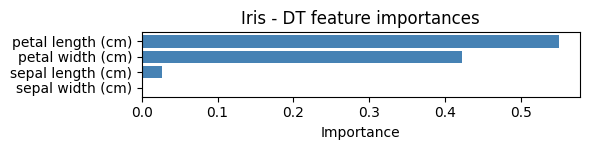

In [7]:
iris = load_iris()
X, y = iris.data, iris.target
print(X)
feat_names = iris.feature_names

# Train a single decision tree
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(max_depth=5).fit(X, y)
# Pass the importances to `plot_imp`
plot_imp(tree.feature_importances_, feat_names, "Iris - DT feature importances")
plt.tight_layout()
plt.show()

Do the same, for `RandomForestClassifier`

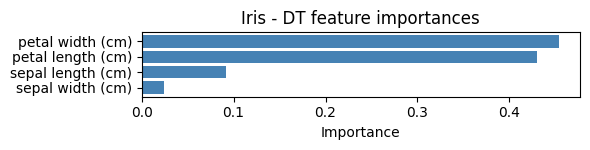

In [10]:
# Train a single decision tree
from sklearn.ensemble import RandomForestClassifier
tree = RandomForestClassifier(max_depth=5).fit(X, y)
# Pass the importances to `plot_imp`
plot_imp(tree.feature_importances_, feat_names, "Iris - DT feature importances")
plt.tight_layout()
plt.show()

## Permutation importance

use the `permutation_importance` function from `sklearn.inspection` (it is already imported) on the fitted decision tree and random forest models.
Pass the `importances_mean` field to the plotting function.


Die **Permutation Importance** misst, wie wichtig einzelne Features für die Modellvorhersage sind.  
Dabei wird die Modellleistung (hier Accuracy) als Maß verwendet:

1. **Modellleistung messen**: Die ursprüngliche Accuracy des Modells wird berechnet.
2. **Feature permutieren**: Die Werte eines Features werden zufällig durchmischt.
3. **Leistung erneut messen**: Die Accuracy nach Permutation wird berechnet.
4. **Differenz bestimmen**: Der Abfall der Accuracy zeigt die Wichtigkeit des Features.
5. **Wiederholungen**: Schritt 2–4 wird mehrmals wiederholt, um stabilere Ergebnisse zu erhalten.

**Interpretation**:  
- Ein hoher Abfall der Accuracy → Feature ist wichtig  
- Ein geringer Abfall der Accuracy → Feature ist weniger wichtig  

**Visualisierung**:  
- Balkendiagramm: mittlerer Accuracy-Abfall pro Feature  
- Fehlerbalken: Standardabweichung über die Wiederholungen


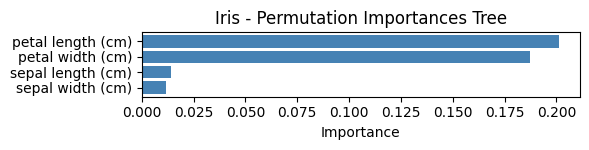

In [14]:
import sklearn.inspection
permutation_importance = sklearn.inspection.permutation_importance(
    tree, X, y, n_repeats=30, random_state=0
)
plot_imp(permutation_importance.importances_mean, feat_names, "Iris - Permutation Importances Tree")
plt.tight_layout()
plt.show()

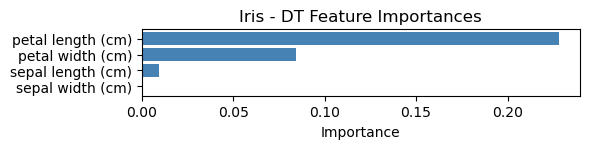

Permutation importance is model-agnostic and can be used for any model. For example, in the next cell apply it to another classifier (for example `MLPClassifier`).

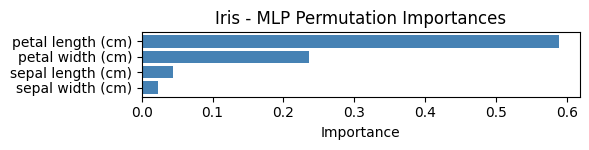

In [16]:
from sklearn.neural_network import MLPClassifier
MLP = MLPClassifier(max_iter=1000).fit(X, y)
permutation_importance = sklearn.inspection.permutation_importance(
    MLP, X, y, n_repeats=30, random_state=0, scoring='accuracy')
plot_imp(permutation_importance.importances_mean, feat_names, "Iris - MLP Permutation Importances")
plt.tight_layout()

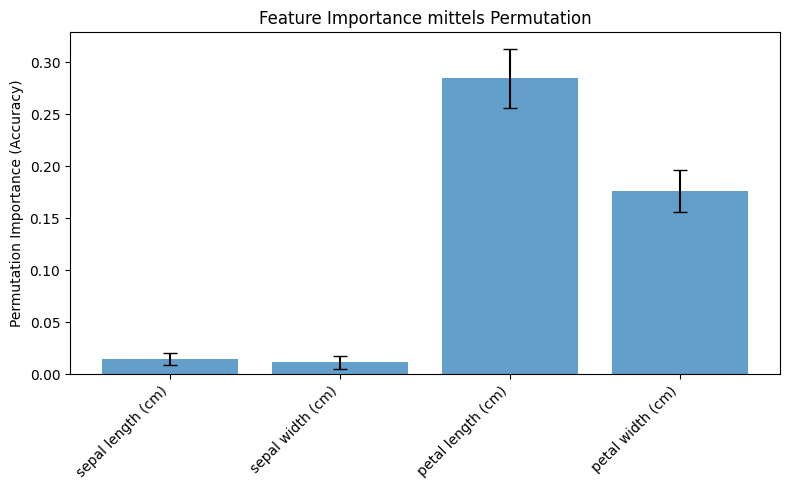

In [15]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
from sklearn.inspection import permutation_importance

# Beispiel-Daten
data = load_iris()
X, y = data.data, data.target
feature_names = data.feature_names

# Modell trainieren
tree = RandomForestClassifier(random_state=0)
tree.fit(X, y)

# Permutation Importance berechnen (Accuracy)
perm_importance = permutation_importance(
    tree,
    X, y,
    n_repeats=30,
    random_state=0,
    scoring="accuracy"
)

# Wichtigkeit und Standardabweichung extrahieren
importances = perm_importance.importances_mean
stds = perm_importance.importances_std

# Bar-Plot erstellen
plt.figure(figsize=(8,5))
plt.bar(range(len(importances)), importances, yerr=stds, align='center', alpha=0.7, capsize=5)
plt.xticks(range(len(importances)), feature_names, rotation=45, ha='right')
plt.ylabel("Permutation Importance (Accuracy)")
plt.title("Feature Importance mittels Permutation")
plt.tight_layout()
plt.show()
